You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L06_frequentist.ipynb)

The model is fully implemented for _any_ dataset. No need to manually retrieve the minimum of _aic_, but only to select the relevant interval.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

In [2]:
data=np.load('/Users/simoneabeni/Desktop/GitHub/reps/astrostatistics_bicocca_2026/solutions/formationchannels.npy')

Histogramming the data

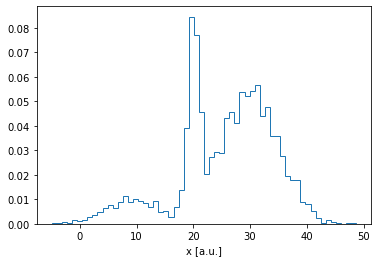

In [3]:
plt.hist(data,histtype='step',bins=60,density=True);
plt.xlabel('x [a.u.]')
plt.show()

Set `x_min` and `x_max`

In [4]:
x_min, x_max = -10, 50

Compute the AIC for each of the $N$ fits

In [5]:
#compute aic
N=10
aic = np.empty(N)
for i in np.arange(1,N+1):
    aic[i-1] = GaussianMixture(i).fit(data).aic(data)

#-----------------------

#index of the minimum +1, input to GaussianMixture(k).fit(data)
k=int(np.argwhere(aic == np.min(aic)).flatten()[0])+1
print("The preferred model consists of {} Gaussians".format(k))

The preferred model consists of 3 Gaussians


Plot $N$ vs AIC

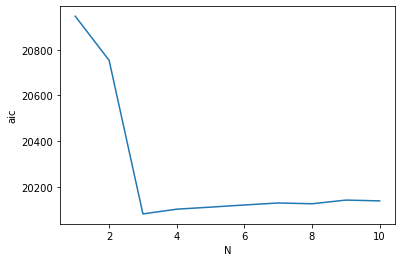

In [6]:
plt.plot(np.arange(1,N+1),aic);
plt.xlabel('N')
plt.ylabel('aic')
plt.show()

Plot of the Gaussian functions and their mixture

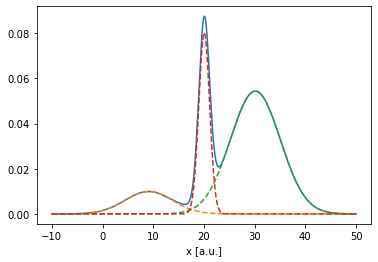

In [7]:
xgrid = np.linspace(x_min,x_max,10**5)

#-----------------------

#Gaussian mixture algorithm
gm3 = GaussianMixture(k).fit(data) #GM fit with 'k' computed above
gm3_means=gm3.means_.flatten() #array of means
gm3_dev=((gm3.covariances_)**0.5).flatten() #array of sigmas; take square-root of the values
gm3_weights=gm3.weights_.flatten() #array of weights

#-----------------------

#generate the k weighted Gaussians
y = np.array([w*norm.pdf(xgrid,loc=x_0,scale=s) for (w,x_0,s) in zip(gm3_weights,gm3_means,gm3_dev)])
#generate the desired linear combinations
Y=np.sum(y,axis=0,keepdims=True).flatten()

#-----------------------

fig, ax = plt.subplots()
#for yi in Y:
plt.plot(xgrid,Y,ls='-')
for yi in y:
    plt.plot(xgrid,yi,ls='--')
plt.xlabel('x [a.u.]')
plt.show()

Plot of the preferred solution on top of the input data

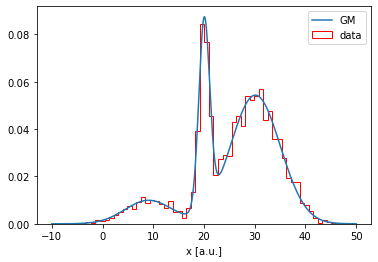

In [8]:
fig, ax = plt.subplots()
plt.plot(xgrid,Y,ls='-',label='GM')
plt.hist(data,histtype='step',bins=60,density=True,color='red',label='data');
plt.xlabel('x [a.u.]')
plt.legend()
plt.show()

# [Optional] Class labels

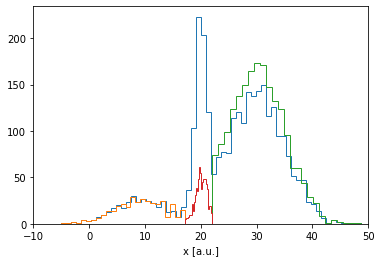

In [11]:
"""
To each data point we assign the label i={1,2,3} corresponding to the Gaussian component with the highest density
"""
P=gm3.predict_proba(data) #(N,k)-array containing the density of each Gaussian component for each data point

#-----------------------

fig, ax = plt.subplots()
plt.hist(data,histtype='step',bins=60);
for i in np.arange(k):
    #select the sub-sample of 'data' with maximum value at 'i'. i={0,1,2}
    plt.hist(data[P.argmax(axis=1)==i],histtype='step',bins=25)
plt.xlabel('x [a.u.]')
plt.xlim((x_min,x_max))
plt.show()

**Comment** The result is not great. Label quality may depend on how well-separated the Gaussians are relative to their standard deviations.